In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_excel('/content/drive/MyDrive/KT ML Internship/Project: Retail Transaction/dataset/Online Retail.xlsx')

# 1. Data Understanding

In [3]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
df1= df.copy()

In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# 2. Data Cleaning and Preparation
Handling Missing Values

In [6]:
df1.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [7]:
df1.loc[df['Description'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


In [8]:
df1.loc[np.where(df1['Description'].isnull() & df1['CustomerID'].isnull())]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
535322,581199,84581,NaN,-2,2011-12-07 18:26:00,0.0,NaN,United Kingdom
535326,581203,23406,NaN,15,2011-12-07 18:31:00,0.0,NaN,United Kingdom
535332,581209,21620,NaN,6,2011-12-07 18:35:00,0.0,NaN,United Kingdom
536981,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom


Description has 1454 null values and CustomerID has 135080 null values (Alot)

All NULL instances in the Description has UnitPrice Zero

All the Description that has null values, there CustomerID also has null value

There might be some system error, better to drop these rows

In [9]:
idx= df.loc[df['Description'].isnull()].index
print(idx.size)
df2= df1.drop(idx, axis=0)

1454


CustomerID has 135080 Null Values: there are two ways to resolve this

- remove all those rows
- check for the pervious or next trancation's InvoiceDate; if it is same then raplce the null value with the transaction's CustomerID values. if its no possible then fill Unknown.

all null values will be removed

In [10]:
df['CustomerID'].unique().size

4373

In [11]:
df2[df2['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,2011-12-09 10:26:00,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,2011-12-09 10:26:00,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,2011-12-09 10:26:00,10.79,NaN,United Kingdom


In [12]:
df2= df2.dropna(subset=['CustomerID'], axis=0)

In [13]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB


Data Analysis: InvoiceNO has two type of trasaction,

InvoiceNO value starting with 'c' indicates return or cancelled

In [14]:
df2['InvoiceNo'].nunique()

22190

i observe that there are 8905 rows where customers has cancelled or returned their product, now i will remove these rows it will not help in customer purchase analysis

In [15]:
idx= df2[df2['InvoiceNo'].astype(str).str.startswith('C')].index
print(idx.size)
df3= df2.drop(idx, axis=0)

8905


In [16]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397924 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397924 non-null  object        
 1   StockCode    397924 non-null  object        
 2   Description  397924 non-null  object        
 3   Quantity     397924 non-null  int64         
 4   InvoiceDate  397924 non-null  datetime64[ns]
 5   UnitPrice    397924 non-null  float64       
 6   CustomerID   397924 non-null  float64       
 7   Country      397924 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.3+ MB


In [17]:
df3.groupby('CustomerID')['InvoiceNo'].nunique()

,InvoiceNo
CustomerID,
12346.0,1
12347.0,7
12348.0,4
12349.0,1
12350.0,1
...,...
18280.0,1
18281.0,1
18282.0,2


In [18]:
df3['TotalValue']= df3['Quantity'] * df['UnitPrice']

In [19]:
df3

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [20]:
df3[df3.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom,2.95
...,...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom,0.39
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom,2.49
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,1.95
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom,2.10


In [21]:
df3.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,397924.000000,397924,397924.000000,397924.000000,397924.000000
mean,13.021823,2011-07-10 23:43:36.912475648,3.116174,15294.315171,22.394749
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,180.420210,NaN,22.096788,1713.169877,309.055588


There are 360 rows that has UnitPrice Value 0; better to remove these as well

In [22]:
idx= df3[df3['UnitPrice']==0].index
df4= df3.drop(idx, axis=0)

Data Formatting

In [23]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalValue   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


In [24]:
df4

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [25]:
df5= df4.astype({'InvoiceNo': int, 'Quantity': int, 'CustomerID': int})

In [26]:
df5['InvoiceDate']= pd.to_datetime(df5['InvoiceDate'])

In [27]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  int64         
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   TotalValue   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(3), object(3)
memory usage: 30.4+ MB


# Outilers Handling

Quantity column has significant large outlier values which directly affects the TotalValue Column

decision:

Taking only rows that are close and under the IQR of Quantity Column (Dataset reduced by 54628 rows)

In [28]:
df5.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,397884.000000,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,560616.934451,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,549234.000000,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,561893.000000,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,572090.000000,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,581587.000000,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,13106.117773,179.331775,NaN,22.097877,1713.141560,309.071041


In [29]:
idx= df5[(df5['Quantity'] >20)].index
print(idx.size)
df6= df5.drop(idx, axis=0)

54628


<Axes: xlabel='Quantity', ylabel='Count'>

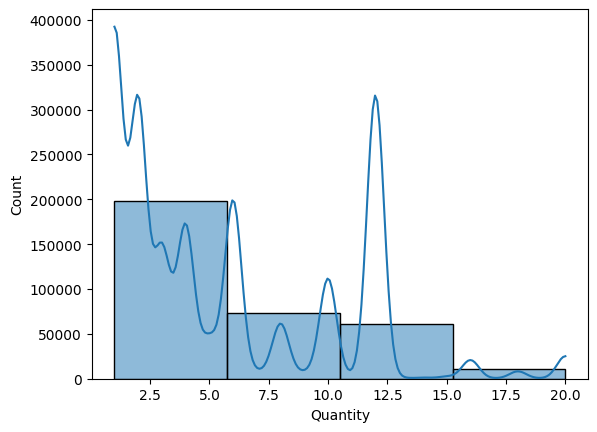

In [30]:
sns.histplot(df6['Quantity'], kde= True, binwidth=5)

In [31]:
df6.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,343256.000000,343256.000000,343256,343256.000000,343256.000000,343256.000000
mean,560694.479313,5.583040,2011-07-11 12:51:29.207996160,3.412653,15335.317696,13.455103
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,549235.000000,2.000000,2011-04-07 11:16:00,1.250000,14032.000000,3.900000
50%,561925.500000,4.000000,2011-08-01 12:38:00,2.080000,15252.000000,10.200000
75%,572287.000000,10.000000,2011-10-23 12:26:00,3.750000,16839.000000,17.400000
max,581587.000000,20.000000,2011-12-09 12:50:00,8142.750000,18287.000000,8142.750000
std,13161.413130,4.606046,NaN,23.746169,1707.168117,27.853324


UnitPrice Also has outliers that are affecting the totalValue Column

descision:
Drop those rows with UnitPrice > 10

<Axes: ylabel='UnitPrice'>

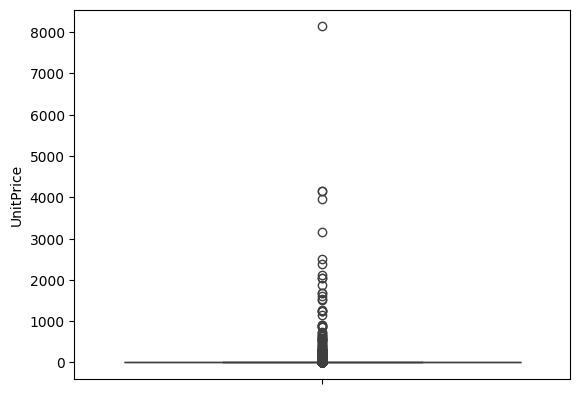

In [32]:
sns.boxplot(df6['UnitPrice'])

In [35]:
idx= df6[df6['UnitPrice'] > 10].index
print(idx.size)
df7= df6.drop(idx, axis=0)

10679


<Axes: ylabel='UnitPrice'>

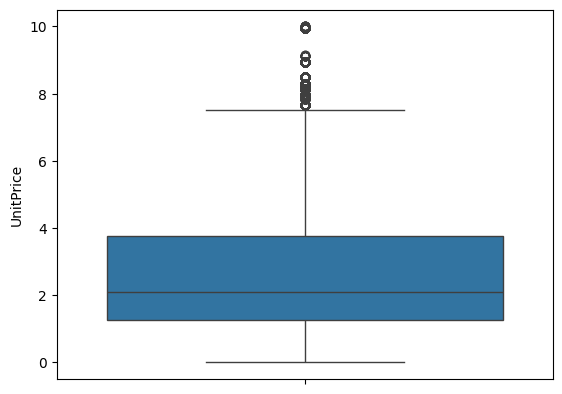

In [36]:
sns.boxplot(df7['UnitPrice'])

In [38]:
df7.describe()

,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalValue
count,332577.000000,332577.000000,332577,332577.000000,332577.000000,332577.000000
mean,560727.801279,5.679867,2011-07-11 19:32:44.379977984,2.745362,15350.456021,12.374791
min,536365.000000,1.000000,2010-12-01 08:26:00,0.001000,12347.000000,0.001000
25%,549245.000000,2.000000,2011-04-07 11:59:00,1.250000,14048.000000,3.750000
50%,562031.000000,4.000000,2011-08-01 17:37:00,2.080000,15296.000000,9.950000
75%,572295.000000,10.000000,2011-10-23 13:49:00,3.750000,16871.000000,17.000000
max,581587.000000,20.000000,2011-12-09 12:50:00,10.000000,18287.000000,199.000000
std,13165.169558,4.618117,NaN,2.203642,1703.806717,12.194086


# 3. Exploratory Data Analysis

<Axes: xlabel='TotalValue', ylabel='Count'>

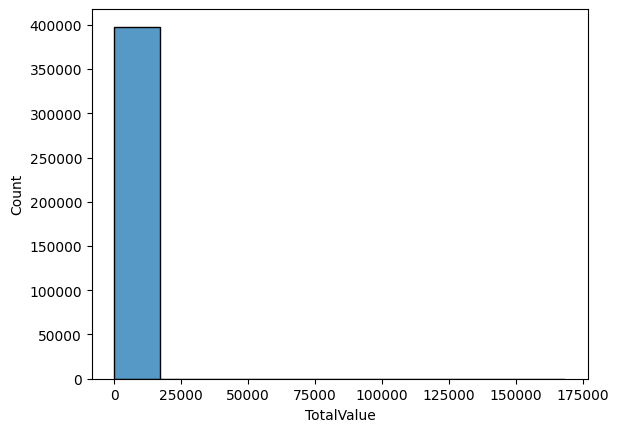

In [ ]:
sns.histplot(df5['TotalValue'], bins=10)

<Axes: xlabel='Description'>

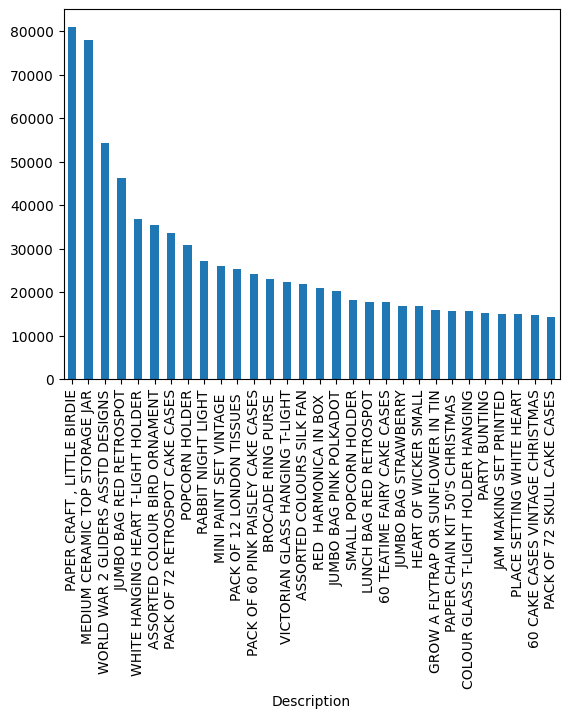

In [ ]:
top_products= df5.groupby('Description')['Quantity'].sum().sort_values(ascending= False).head(30)
top_products.plot(kind= 'bar')

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

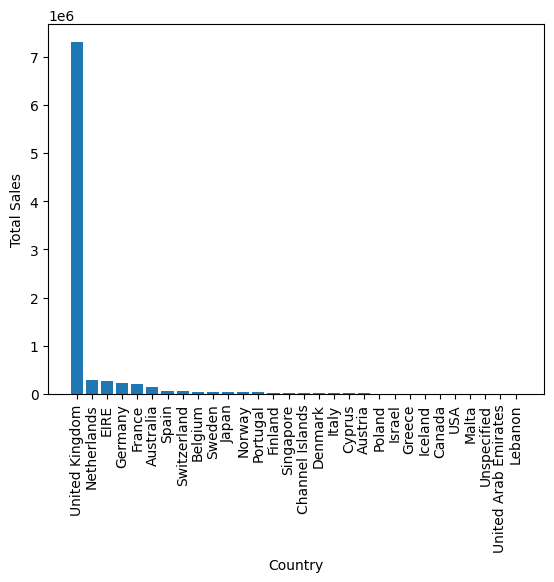

In [ ]:
country_sales= df5.groupby('Country')['TotalValue'].sum().sort_values(ascending= False).head(30)
plt.bar(country_sales.index, country_sales.values)
plt.xticks(rotation= 90)
plt.xlabel('Country')
plt.ylabel('Total Sales')
plt

In [ ]:
country_sales

,TotalValue
Country,
United Kingdom,7308391.554
Netherlands,285446.340
EIRE,265545.900
Germany,228867.140
France,209024.050
Australia,138521.310
Spain,61577.110
Switzerland,56443.950
Belgium,41196.340
